In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("SuperStoreOrders.csv")

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.shape

(51290, 21)

In [5]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum().sort_values(ascending=False)

order_id          0
category          0
order_priority    0
shipping_cost     0
profit            0
discount          0
quantity          0
sales             0
product_name      0
sub_category      0
product_id        0
order_date        0
region            0
market            0
country           0
state             0
segment           0
customer_name     0
ship_mode         0
ship_date         0
year              0
dtype: int64

In [10]:
df = df.drop_duplicates()

In [11]:
df['order_date'].dtype

dtype('O')

In [12]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [13]:
df['order_date'].head()

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: order_date, dtype: datetime64[ns]

In [14]:
df['order_date'].dtype

dtype('<M8[ns]')

In [15]:
df['sales'].dtype

dtype('O')

In [16]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [17]:
df['sales'].dtype

dtype('float64')

In [18]:
df['sales'].isnull().sum()

2630

In [19]:
df.duplicated().sum()

0

In [20]:
df[df['sales'].isnull()][['order_date', 'sales']].head(20)

,order_date,sales
27,2011-01-04,NaN
43,2011-01-05,NaN
58,2011-01-07,NaN
83,2011-01-08,NaN
84,2011-01-08,NaN
100,2011-01-10,NaN
125,2011-01-11,NaN
126,2011-01-11,NaN
163,2011-01-13,NaN
173,2011-01-14,NaN


In [21]:
df.shape

(51290, 21)

In [22]:
df[['order_date', 'sales', 'quantity', 'profit']].isnull().sum()

order_date       0
sales         2630
quantity         0
profit           0
dtype: int64

In [23]:
df = df.dropna(subset=['sales'])

In [24]:
df['sales'].isnull().sum()

0

In [25]:
df.shape

(48660, 21)

In [26]:
df.duplicated().sum()

0

In [27]:
df['sales'].describe()

count    48660.000000
mean       161.017838
std        201.092519
min          0.000000
25%         29.000000
50%         77.000000
75%        208.000000
max        999.000000
Name: sales, dtype: float64

In [28]:
(df['sales'] < 0).sum()

0

In [29]:
df['year'] = df['order_date'].dt.year
df[['order_date', 'year']].head()

,order_date,year
0,2011-01-01,2011
1,2011-01-01,2011
2,2011-01-01,2011
3,2011-01-01,2011
4,2011-01-01,2011


In [30]:
df['month'] = df['order_date'].dt.month
df[['order_date', 'year', 'month']].head()

,order_date,year,month
0,2011-01-01,2011,1
1,2011-01-01,2011,1
2,2011-01-01,2011,1
3,2011-01-01,2011,1
4,2011-01-01,2011,1


In [31]:
df['year_month'] = df['order_date'].dt.to_period('M')
df[['order_date', 'year_month']].head()

,order_date,year_month
0,2011-01-01,2011-01
1,2011-01-01,2011-01
2,2011-01-01,2011-01
3,2011-01-01,2011-01
4,2011-01-01,2011-01


In [32]:
monthly_sales = df.groupby('year_month')['sales'].sum().reset_index()

In [33]:
monthly_sales.head()

,year_month,sales
0,2011-01,64363.0
1,2011-02,60848.0
2,2011-03,78983.0
3,2011-04,80698.0
4,2011-05,91536.0


In [34]:
monthly_sales['year_month'] = monthly_sales['year_month'].dt.to_timestamp()

In [35]:
monthly_sales.head()

,year_month,sales
0,2011-01-01,64363.0
1,2011-02-01,60848.0
2,2011-03-01,78983.0
3,2011-04-01,80698.0
4,2011-05-01,91536.0


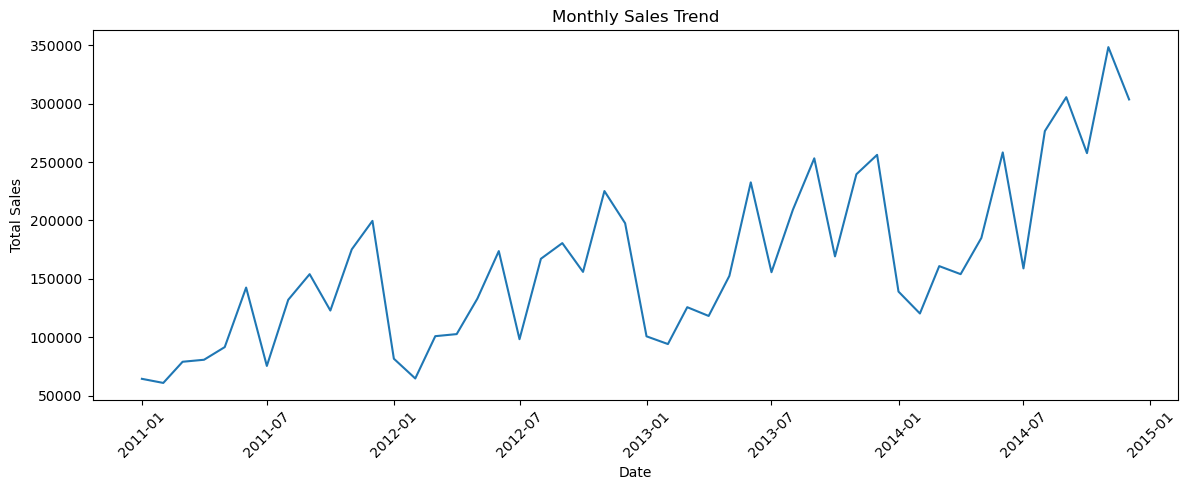

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

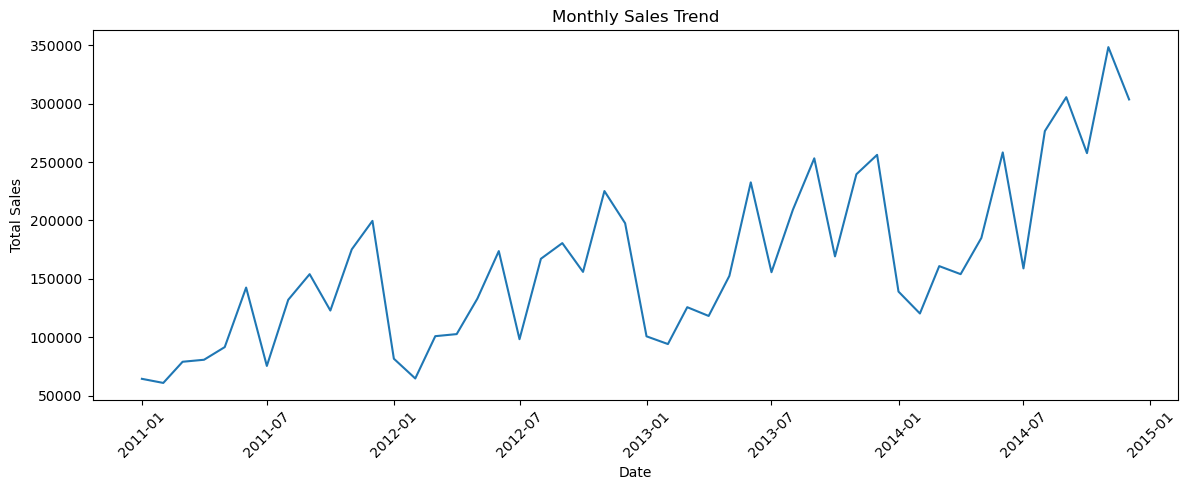

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Monthly Sales Trend.png', dpi=300)

plt.show()

In [39]:
yearly_sales = df.groupby('year')['sales'].sum().reset_index()
yearly_sales

,year,sales
0,2011,1378151.0
1,2012,1681499.0
2,2013,2107021.0
3,2014,2668457.0


In [43]:
import os

os.makedirs('charts', exist_ok=True)

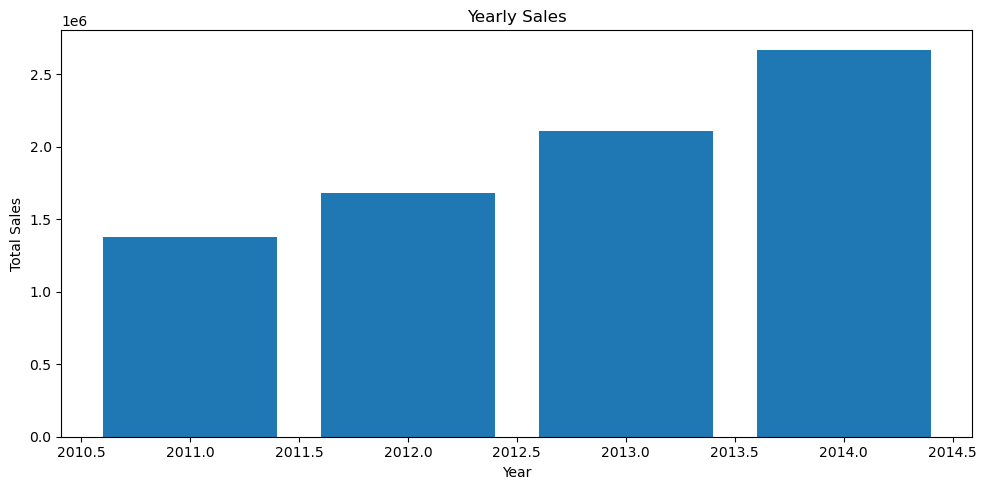

In [45]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales['year'],
    yearly_sales['sales']
)

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.savefig('yearly_sales.png', dpi=300)

plt.show()

In [46]:
category_sales = df.groupby('category')['sales'].sum().reset_index()

category_sales

,category,sales
0,Furniture,2406605.0
1,Office Supplies,2790258.0
2,Technology,2638265.0


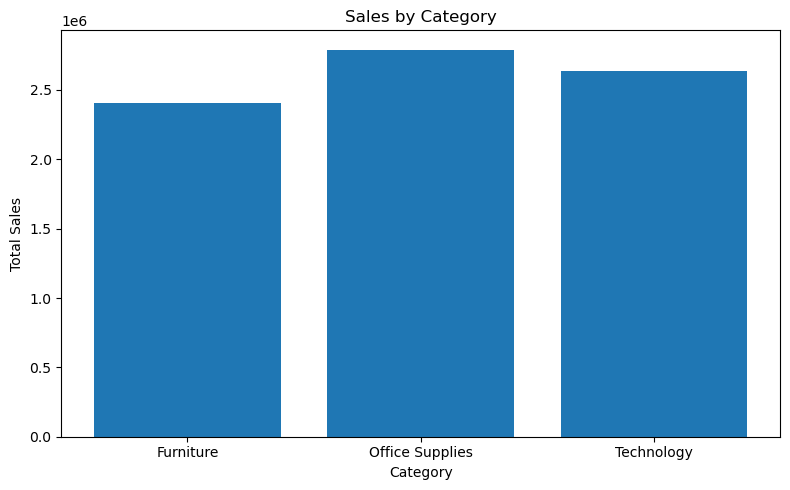

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_sales['category'],
    category_sales['sales']
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.savefig('sales_by_category.png', dpi=300)

plt.show()

In [48]:
category_sales.sort_values('sales', ascending=False)

,category,sales
1,Office Supplies,2790258.0
2,Technology,2638265.0
0,Furniture,2406605.0


In [49]:
region_sales = df.groupby('region')['sales'].sum().reset_index()

region_sales

,region,sales
0,Africa,538115.0
1,Canada,50314.0
2,Caribbean,251441.0
3,Central,1806638.0
4,Central Asia,389506.0
5,EMEA,575562.0
6,East,366492.0
7,North,790546.0
8,North Asia,453686.0
9,Oceania,625382.0


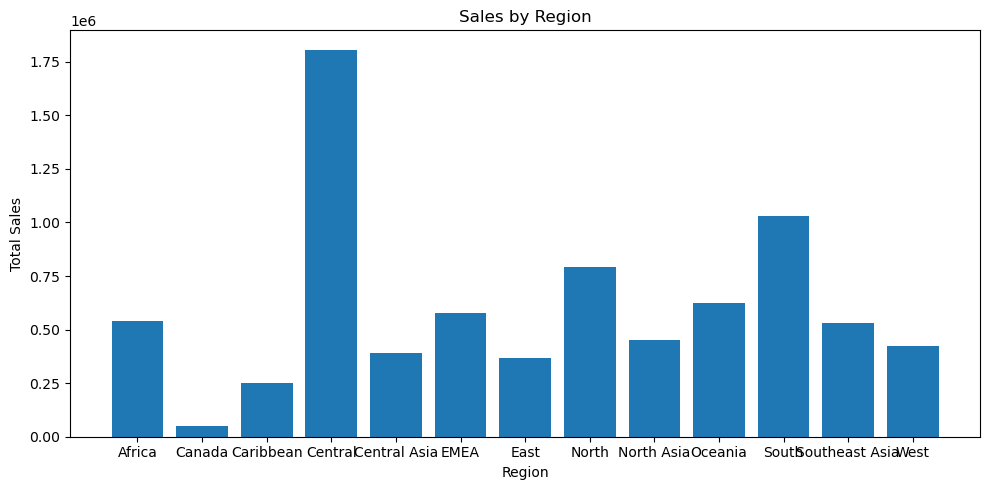

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(
    region_sales['region'],
    region_sales['sales']
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.savefig('sales_by_region.png', dpi=300)

plt.show()

In [51]:
monthly_sales['moving_average_3'] = (
    monthly_sales['sales']
    .rolling(window=3)
    .mean()
)

In [52]:
monthly_sales.head()

,year_month,sales,moving_average_3
0,2011-01-01,64363.0,NaN
1,2011-02-01,60848.0,NaN
2,2011-03-01,78983.0,68064.666667
3,2011-04-01,80698.0,73509.666667
4,2011-05-01,91536.0,83739.000000


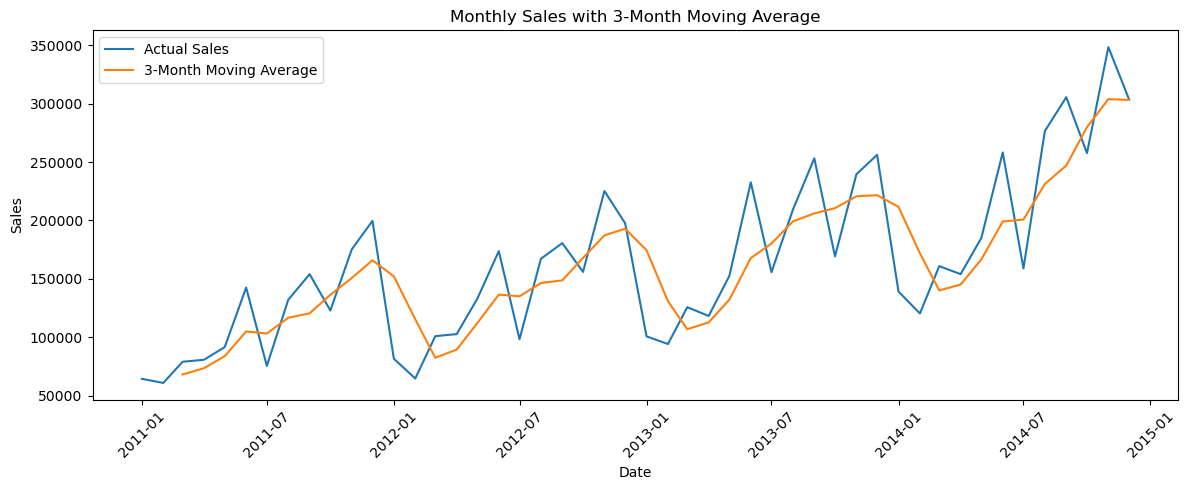

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales'],
    label='Actual Sales'
)

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['moving_average_3'],
    label='3-Month Moving Average'
)

plt.title('Monthly Sales with 3-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('moving_average.png', dpi=300)

plt.show()

In [54]:
monthly_sales.head()

,year_month,sales,moving_average_3
0,2011-01-01,64363.0,NaN
1,2011-02-01,60848.0,NaN
2,2011-03-01,78983.0,68064.666667
3,2011-04-01,80698.0,73509.666667
4,2011-05-01,91536.0,83739.000000


In [55]:
monthly_sales['time_index'] = np.arange(len(monthly_sales))
monthly_sales.head()

,year_month,sales,moving_average_3,time_index
0,2011-01-01,64363.0,NaN,0
1,2011-02-01,60848.0,NaN,1
2,2011-03-01,78983.0,68064.666667,2
3,2011-04-01,80698.0,73509.666667,3
4,2011-05-01,91536.0,83739.000000,4


In [56]:
from sklearn.linear_model import LinearRegression

In [58]:
X = monthly_sales[['time_index']]
y = monthly_sales['sales']


split_point = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

In [59]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 38
Testing data: 10


In [60]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    'Date': monthly_sales['year_month'].iloc[split_point:],
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results

,Date,Actual Sales,Predicted Sales
38,2014-03-01,160887.0,201124.378378
39,2014-04-01,154016.0,204115.813437
40,2014-05-01,185021.0,207107.248495
41,2014-06-01,258276.0,210098.683554
42,2014-07-01,158948.0,213090.118613
43,2014-08-01,276557.0,216081.553671
44,2014-09-01,305570.0,219072.988730
45,2014-10-01,257664.0,222064.423788
46,2014-11-01,348457.0,225055.858847
47,2014-12-01,303659.0,228047.293905


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 59632.77564284933
RMSE: 65742.35868595213
R² Score: 0.04660400673309084


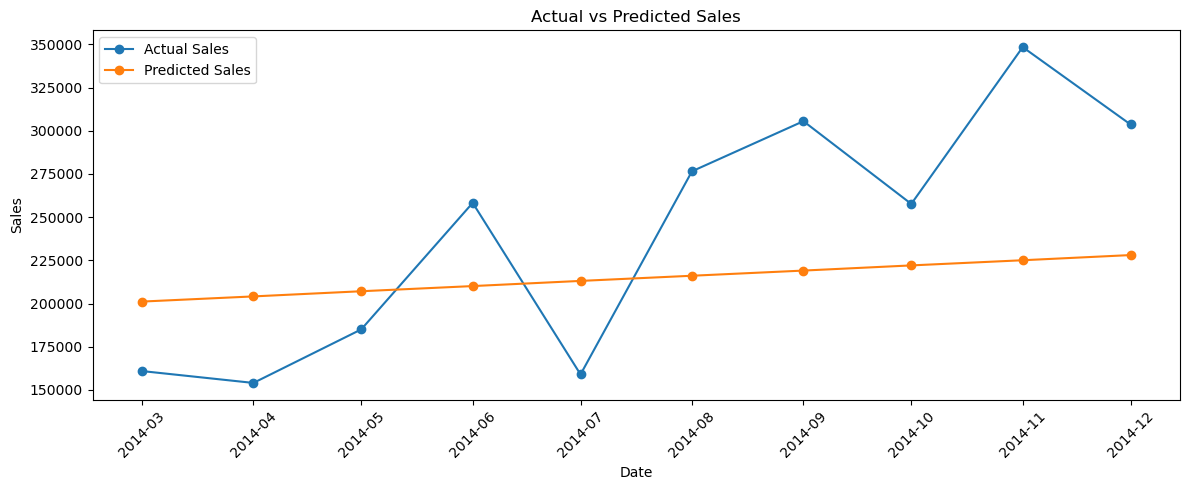

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(
    results['Date'],
    results['Actual Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    results['Date'],
    results['Predicted Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('actual_vs_predicted.png', dpi=300)

plt.show()

In [66]:
future_periods = 6

future_time_index = np.arange(
    len(monthly_sales),
    len(monthly_sales) + future_periods
).reshape(-1, 1)

In [71]:
X = monthly_sales[['time_index']]

In [73]:
future_periods = 6

future_time_index = pd.DataFrame({
    'time_index': np.arange(
        len(monthly_sales),
        len(monthly_sales) + future_periods
    )
})

In [74]:
future_predictions = model.predict(future_time_index)

In [75]:
future_predictions

array([231038.72896378, 234030.16402232, 237021.59908086, 240013.0341394 ,
       243004.46919794, 245995.90425648])

In [76]:
last_date = monthly_sales['year_month'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

In [77]:
future_forecast = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_predictions
})

future_forecast

,Date,Forecasted Sales
0,2015-01-01,231038.728964
1,2015-02-01,234030.164022
2,2015-03-01,237021.599081
3,2015-04-01,240013.034139
4,2015-05-01,243004.469198
5,2015-06-01,245995.904256


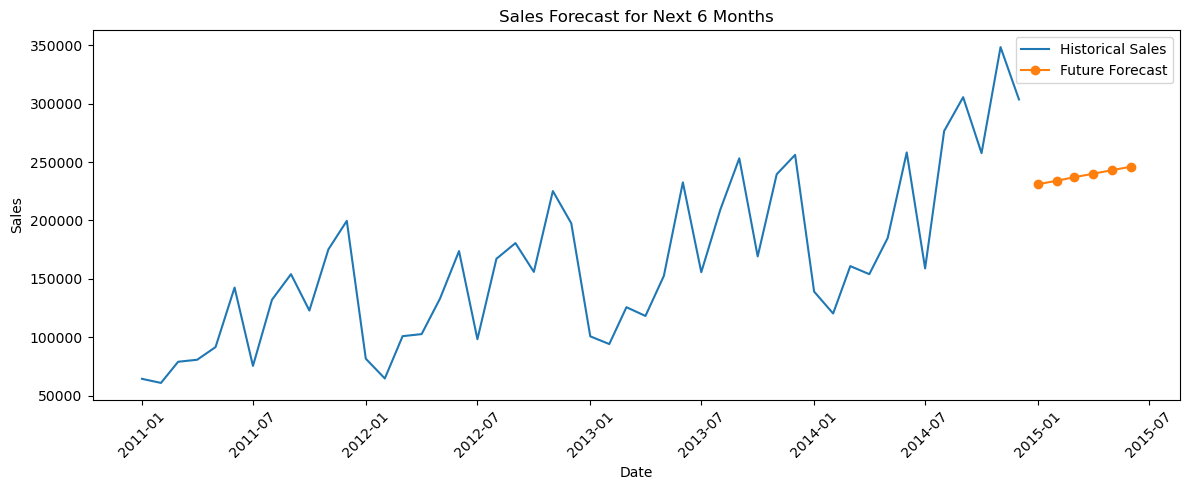

In [78]:
plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales'],
    label='Historical Sales'
)

# Future forecast
plt.plot(
    future_forecast['Date'],
    future_forecast['Forecasted Sales'],
    marker='o',
    label='Future Forecast'
)

plt.title('Sales Forecast for Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('future_sales_forecast.png', dpi=300)

plt.show()

In [79]:
future_forecast

,Date,Forecasted Sales
0,2015-01-01,231038.728964
1,2015-02-01,234030.164022
2,2015-03-01,237021.599081
3,2015-04-01,240013.034139
4,2015-05-01,243004.469198
5,2015-06-01,245995.904256


In [80]:
future_forecast['Forecasted Sales'].mean()

238517.31661013243

In [81]:
future_forecast['Forecasted Sales'].sum()

1431103.8996607945

In [82]:
import joblib

In [83]:
joblib.dump(model, 'sales_forecasting_model.pkl')

['sales_forecasting_model.pkl']

In [84]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 59632.77564284933
RMSE: 65742.35868595213
R² Score: 0.04660400673309084


In [85]:
print("Average Forecasted Sales:", future_forecast['Forecasted Sales'].mean())
print("Total Forecasted Sales:", future_forecast['Forecasted Sales'].sum())

Average Forecasted Sales: 238517.31661013243
Total Forecasted Sales: 1431103.8996607945


In [87]:
future_forecast.to_csv(
    'future_sales_forecast.csv',
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


In [89]:
import joblib

joblib.dump(
    model,
    'sales_forecasting_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [90]:
import joblib

joblib.dump(model, 'Sales_forecasting_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [93]:
future_forecast.to_csv('Future_sales_forecast.csv', index=False)

In [94]:
future_forecast.to_excel(
    'future_sales_forecast.xlsx',
    index=False
)